[TD3] PyTorch 2.10.0+cu128 | device = cuda
  F-18 TD3 TRAINER  —  CONTINUOUS 180° HEADING CHANGE
  State dim    : 11
  Action dim   : 2  (ψ̇_cmd ∈ [±30.0°/s], ḣ_cmd ∈ [±20.0m/s])
  Episodes     : 3,000
  Warmup steps : 3,000
  Actor hidden : Sequential(
  (0): Linear(in_features=11, out_features=256, bias=True)
  (1): ReLU()
  (2): Linear(in_features=256, out_features=256, bias=True)
  (3): ReLU()
  (4): Linear(in_features=256, out_features=2, bias=True)
)
-----------------------------------------------------------------
  Ep   200 | AvgR=  8947.6 | Suc= 83.0% | HErr=   8.0° | CL=43765.066 | σ=0.377 | t=184s
  Ep   400 | AvgR= 38671.1 | Suc=  1.5% | HErr=  15.2° | CL=101859.298 | σ=0.353 | t=817s
  [EVAL ep=500] reward=38915.6  success=0.0%  herr=15.9°
[TD3] Saved to td3_f18_best.pt
  Ep   600 | AvgR= 40287.1 | Suc=  7.5% | HErr=  11.1° | CL=111482.286 | σ=0.330 | t=1437s
  Ep   800 | AvgR= 41845.0 | Suc=  1.0% | HErr=  11.5° | CL=116617.092 | σ=0.307 | t=2070s
  Ep 1,000 | AvgR= 41319

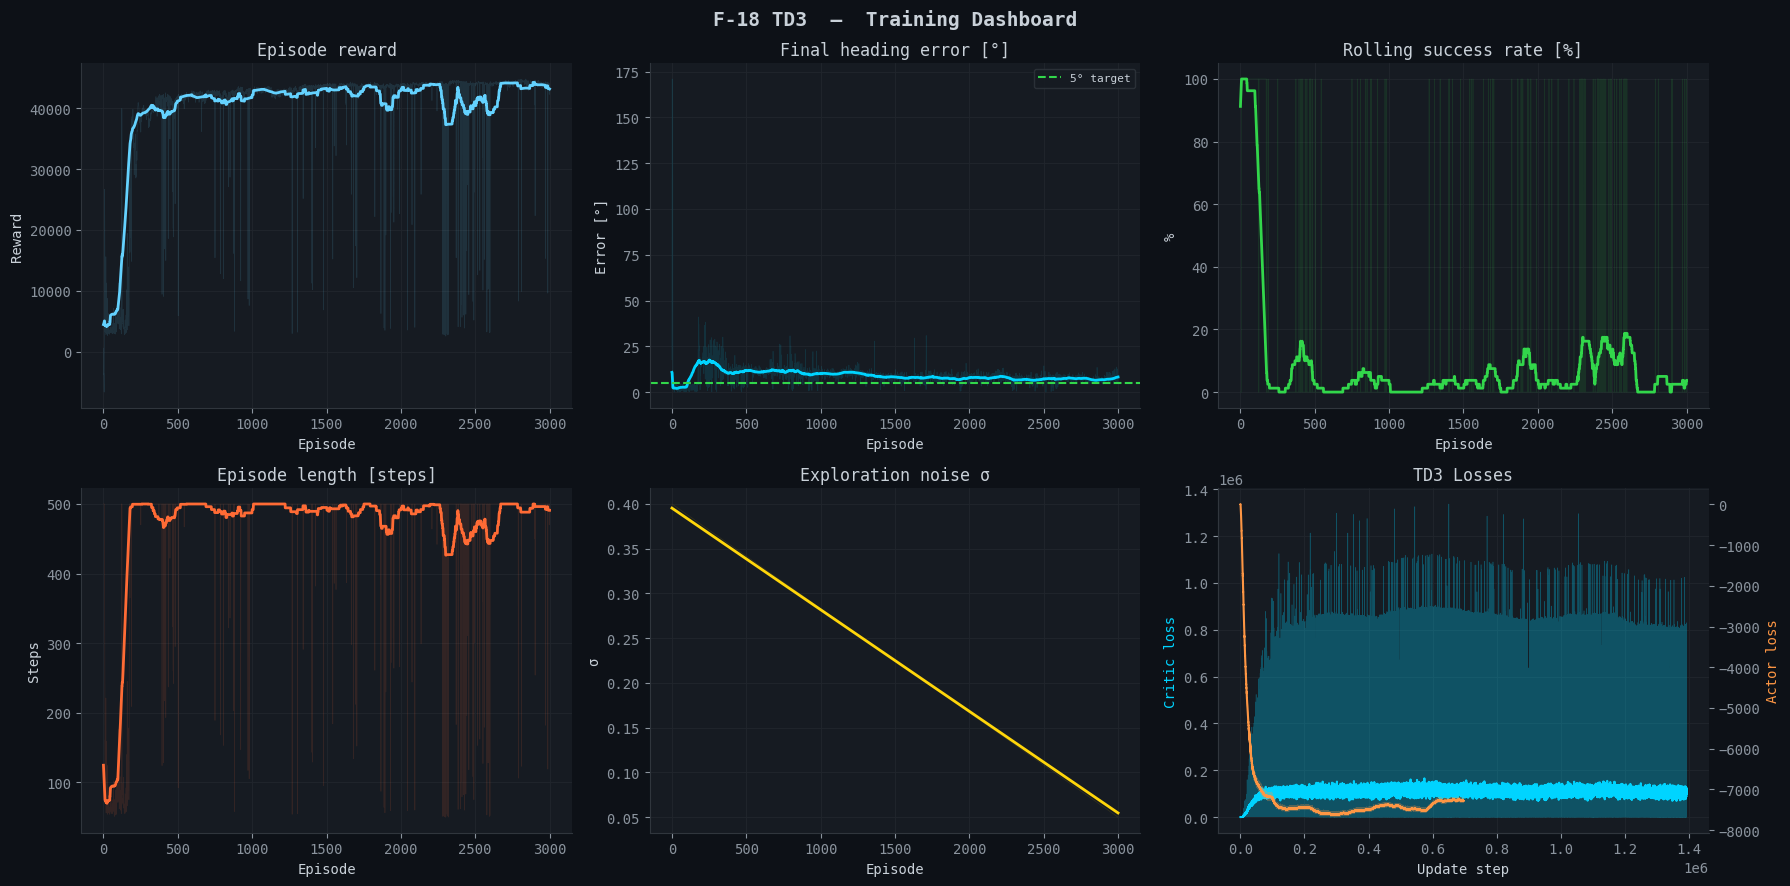

[Saved] td3_training.png
[Plotting] Maneuver state traces …


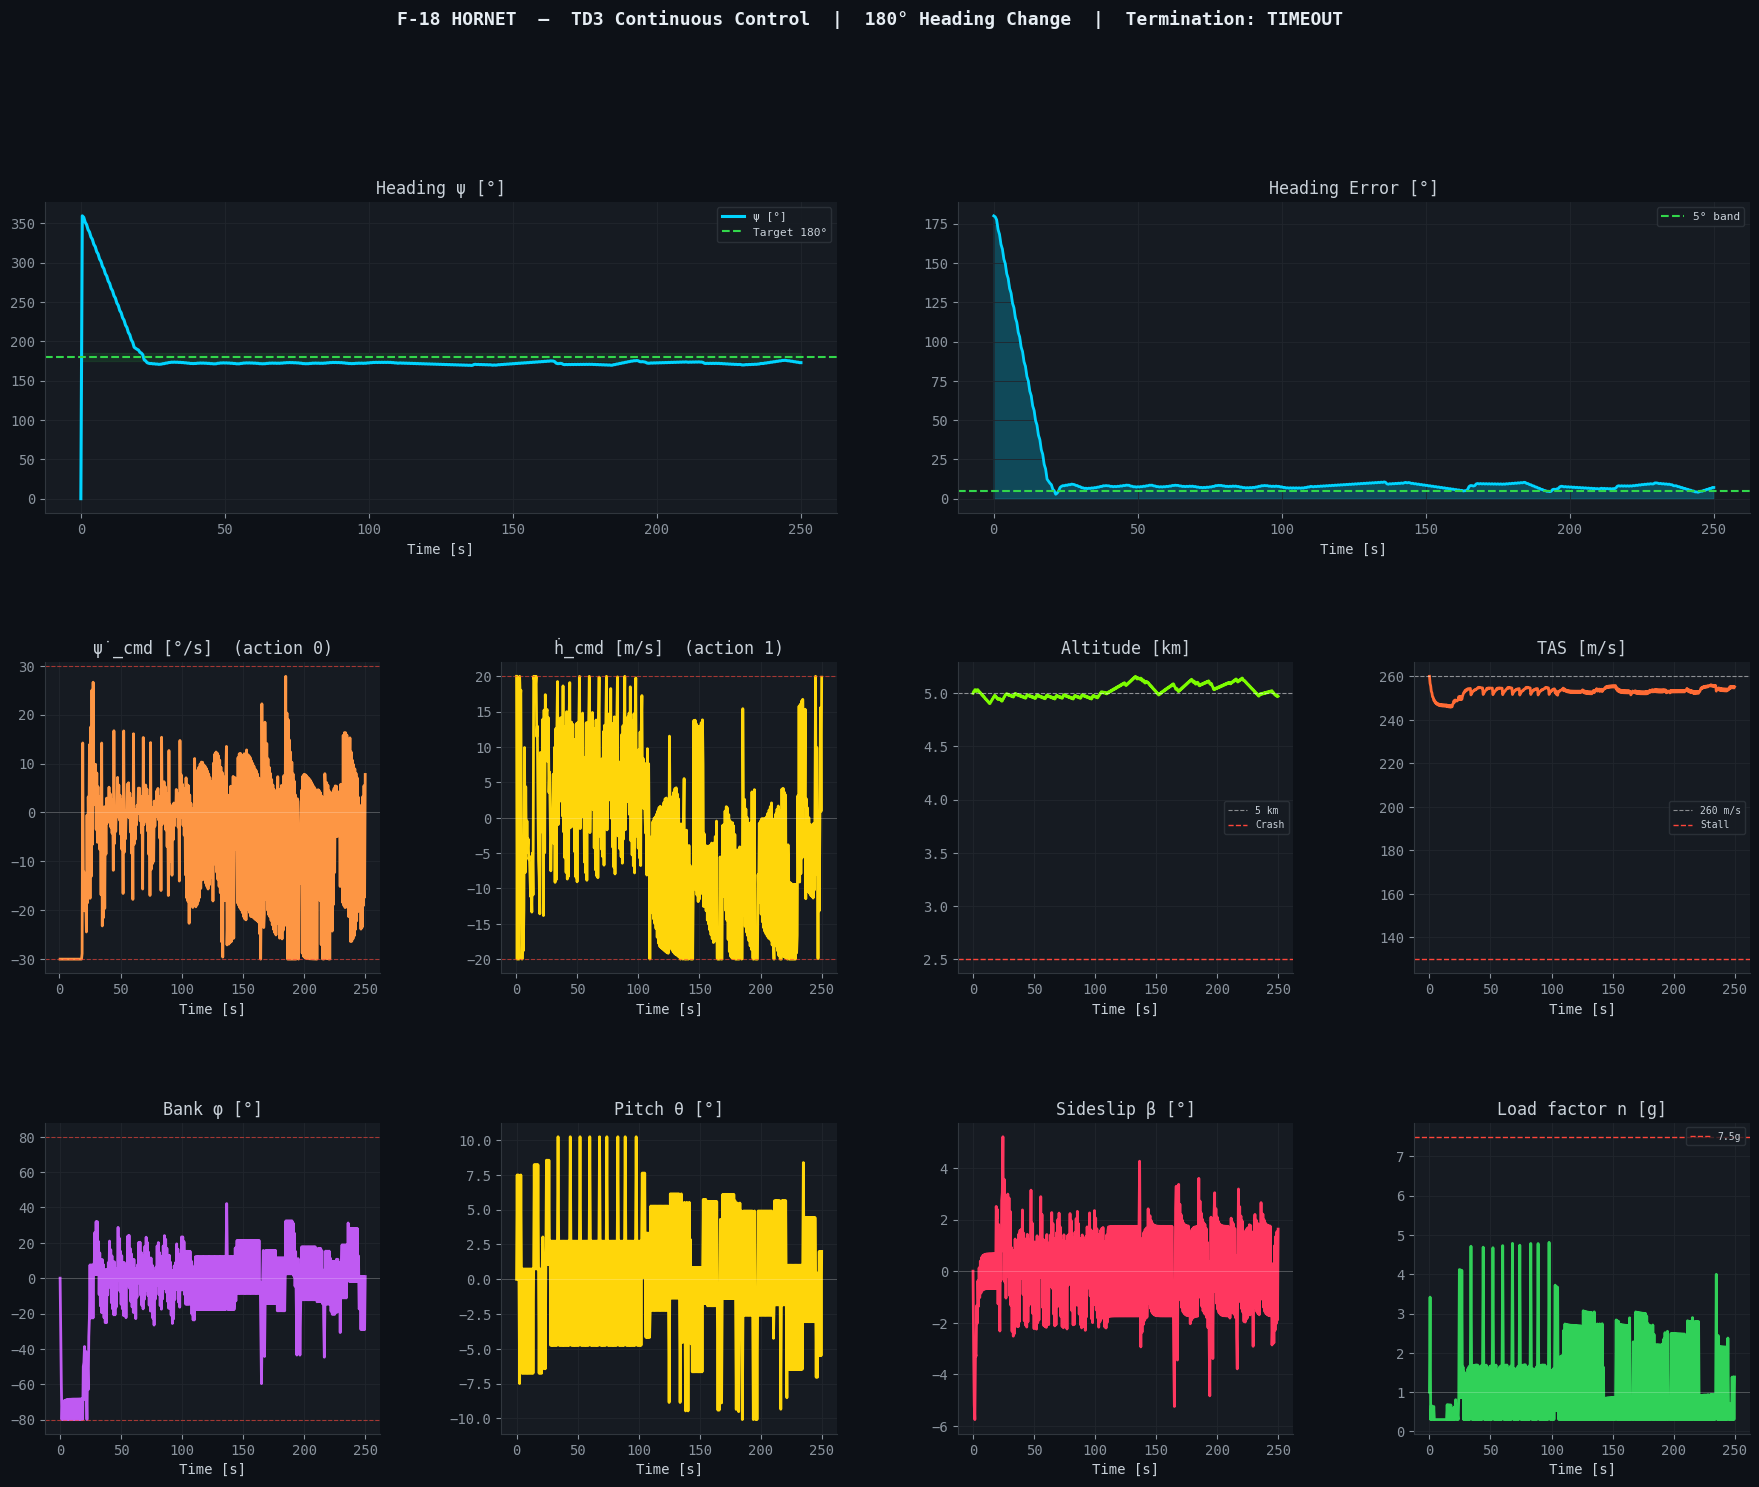

[Saved] td3_maneuver.png
[Plotting] Action phase planes …


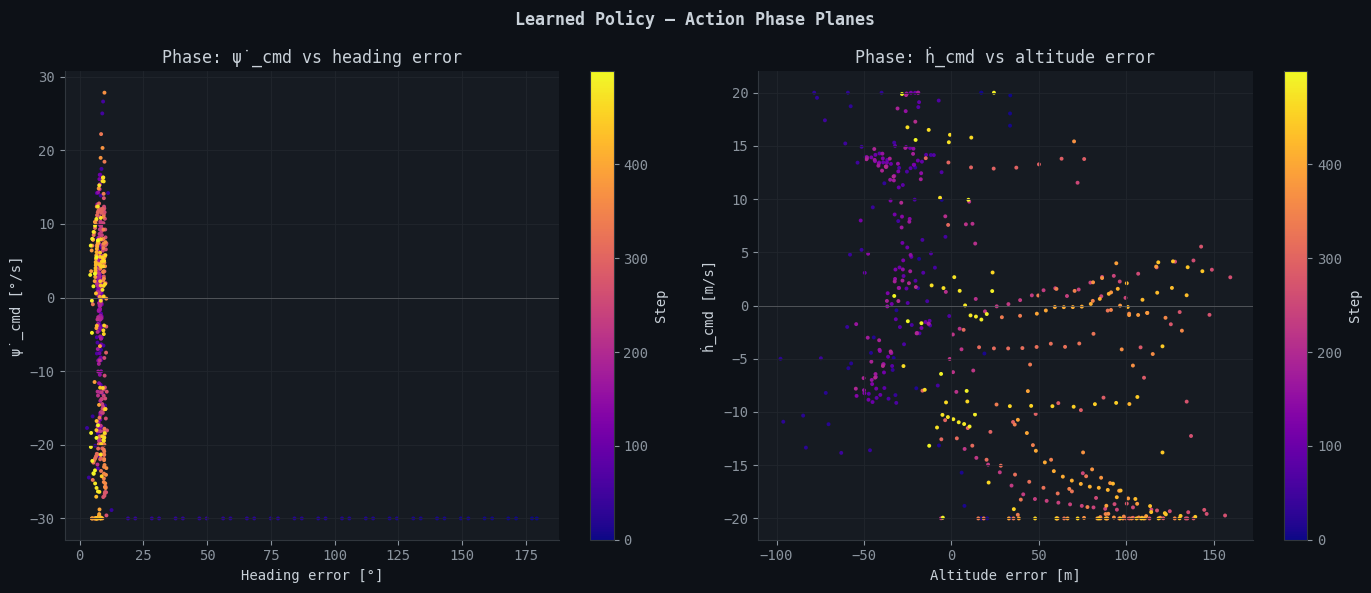

[Saved] td3_phase.png
[Plotting] Ground track …


AttributeError: 'Annotation' object has no property 'xycoords2'

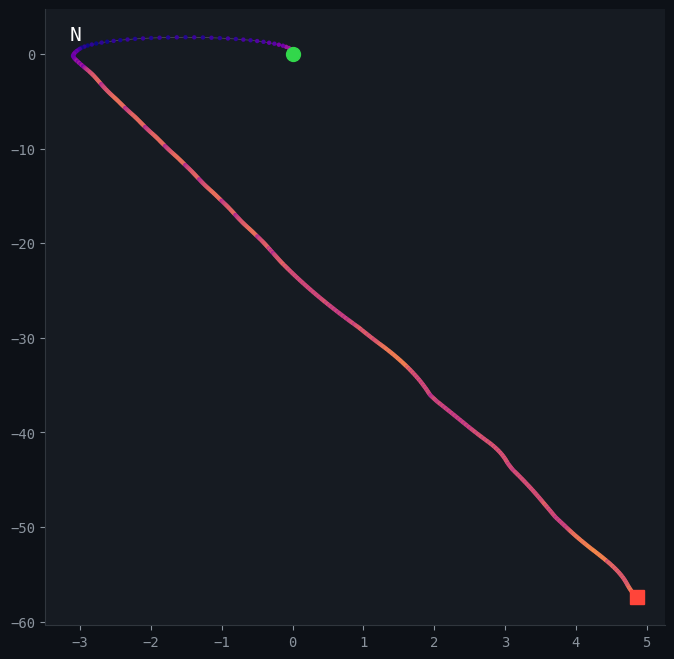

In [1]:
"""
=============================================================================
  F-18 HORNET  —  TD3 (TWIN DELAYED DDPG) FOR 180° HEADING CHANGE
  Continuous State + Continuous Action (Heading Command + Altitude Command)
=============================================================================

State vector  (11-dim, all normalised to [-1, 1]):
  [sin(ψ_err), cos(ψ_err), h_err_norm, V_norm, φ_norm, θ_norm,
   β_norm, n_norm, ψ̇_norm, ḣ_norm, V̇_norm]

Action vector (2-dim, range [-1, 1] → rescaled):
  a[0] : Δψ_cmd  → desired heading-rate command  [-30, +30] deg/s
  a[1] : Δh_cmd  → desired altitude-rate command  [-20, +20] m/s

Algorithm: TD3 (Fujimoto et al. 2018).0
  • Twin critics → min(Q1, Q2) for TD targets
  • Delayed actor update (every d=2 critic steps)
  • Target policy smoothing noise on critic update
  • Soft target network updates (τ = 0.005)
  • Replay buffer (size 200 000)
  • Gaussian exploration noise with linear decay

Only dependency beyond the std-lib: numpy + matplotlib (+ torch for networks).
=============================================================================
"""

import numpy as np
import random
import copy
import math
import time
import warnings
from collections import deque
from typing import Tuple, List, Dict

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

warnings.filterwarnings("ignore")

# ── Try importing torch; if absent give a clear message ──────────────────────
try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    import torch.optim as optim
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"[TD3] PyTorch {torch.__version__} | device = {DEVICE}")
except ImportError:
    raise SystemExit(
        "\n[ERROR] PyTorch is required.\n"
        "  Install with:  pip install torch torchvision --index-url "
        "https://download.pytorch.org/whl/cpu\n"
    )

# ─────────────────────────────────────────────────────────────────────────────
# 1.  6-DOF F-18 DYNAMICS
# ─────────────────────────────────────────────────────────────────────────────

class F18Dynamics:
    """
    Point-mass, 6-DOF kinematic model of the F/A-18C Hornet.

    Internal state (continuous, physical units)
    ────────────────────────────────────────────
      ψ   heading      [deg]   0 = North, CW positive
      h   altitude     [m]
      V   true airspeed[m/s]
      φ   bank angle   [deg]   RWD positive
      θ   pitch angle  [deg]   nose-up positive
      β   sideslip     [deg]
      n   load factor  [g]

    Control inputs (from RL agent via inner-loop autopilot)
    ────────────────────────────────────────────────────────
      ψ̇_cmd   heading-rate command  [deg/s]   → drives φ via bank-angle demand
      ḣ_cmd    altitude-rate command [m/s]    → drives θ via pitch demand

    Inner-loop autopilot (proportional)
    ─────────────────────────────────────
      φ_demand = clip(K_ψ · (ψ̇_cmd - ψ̇),   ±BANK_MAX)
      θ_demand = clip(K_h  · (ḣ_cmd  - ḣ),  PITCH_MIN..PITCH_MAX)
    """

    # ── Aircraft constants ────────────────────────────────────────────────
    G           = 9.81          # m/s²
    MASS        = 16_651        # kg
    WING_AREA   = 37.16         # m²
    RHO_SL      = 1.225         # kg/m³
    H_SCALE     = 8_500         # m  (ISA exponential scale height)

    # ── Aero coefficients (simplified flat-plate model) ───────────────────
    CD0         = 0.022
    K_IND       = 0.16          # induced drag factor
    CL_alpha    = 5.0           # lift-curve slope  [/rad]
    CL0         = 0.10
    CY_beta     = -0.90         # side-force slope  [/rad]

    # ── Structural / performance limits ───────────────────────────────────
    BANK_MAX         =  80.0    # deg
    BANK_RATE_MAX    =  60.0    # deg/s
    PITCH_MAX        =  25.0    # deg
    PITCH_MIN        = -20.0    # deg
    PITCH_RATE_MAX   =  15.0    # deg/s
    V_MIN            = 130.0    # m/s  (≈ 253 kt)
    V_MAX            = 500.0    # m/s
    BETA_MAX         =  12.0    # deg
    NZ_MAX           =   9.0    # g
    THROTTLE_MAX     =  40.0    # m/s per step velocity authority

    # ── Autopilot gains ───────────────────────────────────────────────────
    K_PSI_DOT   = 4.0           # bank demand per (deg/s) heading-rate error
    K_HDOT      = 1.5           # pitch demand per (m/s) altitude-rate error

    def __init__(self, dt: float = 0.5):
        self.dt = dt
        self.reset()

    def reset(self, heading: float = 0.0):
        self.psi   = heading       # heading [deg]
        self.h     = 5_000.0      # altitude [m]
        self.V     = 260.0        # TAS [m/s]
        self.phi   = 0.0          # bank [deg]
        self.theta = 0.0          # pitch [deg]
        self.beta  = 0.0          # sideslip [deg]
        self.nz    = 1.0          # load factor [g]
        self.hdot  = 0.0          # altitude rate [m/s]
        self.psidot= 0.0          # heading rate [deg/s]
        self.Vdot  = 0.0          # acceleration [m/s²]
        self.steps = 0

    # ── Atmosphere ────────────────────────────────────────────────────────
    def _rho(self) -> float:
        return self.RHO_SL * math.exp(-self.h / self.H_SCALE)

    # ── Aerodynamic forces ────────────────────────────────────────────────
    def _aero(self):
        q_bar = 0.5 * self._rho() * self.V ** 2
        alpha = math.radians(self.theta)
        CL    = min(self.CL0 + self.CL_alpha * alpha, 2.0)
        CD    = self.CD0 + self.K_IND * CL ** 2
        lift  = q_bar * self.WING_AREA * CL
        drag  = q_bar * self.WING_AREA * CD
        return lift, drag

    # ── One integration step ──────────────────────────────────────────────
    def step(self, psi_dot_cmd: float, hdot_cmd: float) -> dict:
        """
        Parameters
        ──────────
        psi_dot_cmd : desired heading rate  [deg/s],  range ±30
        hdot_cmd    : desired altitude rate [m/s],    range ±20

        Returns
        ───────
        dict with current continuous state values.
        """
        self.steps += 1

        # ── Inner-loop autopilot ──────────────────────────────────────
        phi_demand   = np.clip(
            self.K_PSI_DOT * (psi_dot_cmd - self.psidot),
            -self.BANK_MAX, self.BANK_MAX)
        theta_demand = np.clip(
            self.K_HDOT * (hdot_cmd - self.hdot),
            self.PITCH_MIN, self.PITCH_MAX)

        # ── Rate-limited actuator response ───────────────────────────
        dphi   = np.clip(phi_demand   - self.phi,
                         -self.BANK_RATE_MAX  * self.dt,
                          self.BANK_RATE_MAX  * self.dt)
        dtheta = np.clip(theta_demand - self.theta,
                         -self.PITCH_RATE_MAX * self.dt,
                          self.PITCH_RATE_MAX * self.dt)

        self.phi   = np.clip(self.phi   + dphi,   -self.BANK_MAX,  self.BANK_MAX)
        self.theta = np.clip(self.theta + dtheta,  self.PITCH_MIN,  self.PITCH_MAX)

        # ── Aerodynamics ──────────────────────────────────────────────
        lift, drag = self._aero()

        # ── Load factor ───────────────────────────────────────────────
        phi_rad = math.radians(self.phi)
        self.nz = min((lift * math.cos(phi_rad)) / (self.MASS * self.G),
                       self.NZ_MAX)
        self.nz = max(self.nz, 0.3)

        # ── Heading rate & update (coordinated turn) ──────────────────
        self.psidot = math.degrees(
            (self.G * math.tan(phi_rad)) / max(self.V, 50.0))
        self.psi = (self.psi + self.psidot * self.dt) % 360.0

        # ── Altitude rate & update ────────────────────────────────────
        self.hdot  = self.V * math.sin(math.radians(self.theta))
        self.h    += self.hdot * self.dt

        # ── Velocity (drag bleed + approximate thrust balancing) ──────
        induced_decel = (abs(self.phi) * 0.06 +
                         abs(self.theta) * 0.25 +
                         max(self.nz - 1.0, 0.0) * 1.2)
        # Throttle: proportional controller to maintain 260 m/s
        v_error = 260.0 - self.V
        thrust_accel = np.clip(0.4 * v_error, -self.THROTTLE_MAX,
                                self.THROTTLE_MAX)
        self.Vdot = thrust_accel - induced_decel
        self.V    = np.clip(self.V + self.Vdot * self.dt,
                            self.V_MIN, self.V_MAX)

        # ── Sideslip (roll coupling + decay) ─────────────────────────
        beta_drive = 0.10 * dphi / self.dt
        beta_damp  = -0.55 * self.beta
        self.beta  = np.clip(self.beta + (beta_drive + beta_damp) * self.dt,
                             -self.BETA_MAX, self.BETA_MAX)

        return self._state_dict()

    def _state_dict(self) -> dict:
        return dict(psi=self.psi, h=self.h, V=self.V, phi=self.phi,
                    theta=self.theta, beta=self.beta, nz=self.nz,
                    hdot=self.hdot, psidot=self.psidot, Vdot=self.Vdot)


# ─────────────────────────────────────────────────────────────────────────────
# 2.  OBSERVATION & ACTION SPACES
# ─────────────────────────────────────────────────────────────────────────────

TARGET_HEADING  = 180.0     # degrees
TARGET_ALTITUDE = 5_000.0   # meters

STATE_DIM  = 11             # continuous observation vector dimension
ACTION_DIM = 2              # [psi_dot_cmd, hdot_cmd] both in [-1, 1]

# Action scaling
PSI_DOT_MAX = 30.0          # deg/s maximum heading-rate command
HDOT_MAX    = 20.0          # m/s  maximum altitude-rate command


def _heading_error(psi: float) -> float:
    """Signed shortest-path error to 180° target.  Range (-180, +180]."""
    err = TARGET_HEADING - psi
    # Wrap to (-180, 180]
    while err >  180.0: err -= 360.0
    while err <= -180.0: err += 360.0
    return err


def build_observation(sv: dict) -> np.ndarray:
    """
    Construct the 11-dimensional normalised state vector.
    All elements are in approximately [-1, 1].
    """
    herr  = _heading_error(sv['psi'])   # signed, (-180, 180]
    h_err = sv['h'] - TARGET_ALTITUDE   # metres, ±2000 typical

    obs = np.array([
        math.sin(math.radians(herr)),           # 0: sin of heading error
        math.cos(math.radians(herr)),           # 1: cos of heading error
        np.clip(h_err / 2_000.0, -1, 1),        # 2: normalised altitude error
        np.clip((sv['V'] - 260.0) / 130.0, -1,  1), # 3: normalised velocity
        np.clip(sv['phi']   / 80.0,  -1, 1),    # 4: normalised bank
        np.clip(sv['theta'] / 25.0,  -1, 1),    # 5: normalised pitch
        np.clip(sv['beta']  / 12.0,  -1, 1),    # 6: normalised sideslip
        np.clip((sv['nz'] - 1.0) / 8.0, -1, 1), # 7: normalised excess load
        np.clip(sv['psidot'] / 30.0, -1, 1),    # 8: normalised heading rate
        np.clip(sv['hdot']   / 20.0, -1, 1),    # 9: normalised altitude rate
        np.clip(sv['Vdot']   / 10.0, -1, 1),    # 10: normalised acceleration
    ], dtype=np.float32)
    return obs


def scale_action(raw: np.ndarray) -> Tuple[float, float]:
    """Map tanh-squashed [-1,1] action to physical commands."""
    psi_dot_cmd = float(raw[0]) * PSI_DOT_MAX   # deg/s
    hdot_cmd    = float(raw[1]) * HDOT_MAX       # m/s
    return psi_dot_cmd, hdot_cmd


# ─────────────────────────────────────────────────────────────────────────────
# 3.  REWARD FUNCTION
# ─────────────────────────────────────────────────────────────────────────────

def compute_reward(sv_prev: dict, sv: dict, done: bool, cause: str) -> float:
    """
    Dense, shaped reward for the 180° heading change task.

    Components
    ──────────
    r_heading    : Gaussian potential on heading error (main signal)
    r_altitude   : Quadratic penalty for altitude deviation
    r_velocity   : Penalty for speed excursion from 260 m/s
    r_sideslip   : Penalty for uncoordinated flight
    r_nz         : Penalty for excessive g-loading
    r_roll_rate  : Penalty for rapid bank changes (comfort/structural)
    r_terminal   : Large bonus/penalty at episode end
    """
    herr_abs  = abs(_heading_error(sv['psi']))          # 0..180
    herr_prev = abs(_heading_error(sv_prev['psi']))

    # ── 1. Gaussian heading reward ────────────────────────────────────────
    sigma_h = 40.0          # deg — width of the Gaussian
    r_heading = 100.0 * math.exp(-0.5 * (herr_abs / sigma_h) ** 2)

    # ── 2. Heading progress bonus ─────────────────────────────────────────
    delta_herr = herr_prev - herr_abs              # positive = improving
    r_progress = 3.0 * delta_herr                  # ~3 pts per deg progress

    # ── 3. Altitude maintenance ───────────────────────────────────────────
    h_err_m = abs(sv['h'] - TARGET_ALTITUDE)
    r_altitude = -0.04 * h_err_m                   # -0.04 per metre off

    # ── 4. Velocity maintenance ───────────────────────────────────────────
    v_err = abs(sv['V'] - 260.0)
    r_velocity = -0.02 * v_err

    # ── 5. Sideslip penalty ───────────────────────────────────────────────
    r_sideslip = -2.0 * abs(sv['beta'])

    # ── 6. Load-factor penalty (only above 6g) ────────────────────────────
    r_nz = -5.0 * max(0.0, sv['nz'] - 6.0)

    # ── 7. Terminal rewards / penalties ───────────────────────────────────
    r_terminal = 0.0
    if cause == 'success':
        # Bonus: larger if close to target altitude and wings level
        wings_level  = 1.0 - abs(sv['phi']) / 80.0
        altitude_ok  = 1.0 - min(h_err_m, 500.0) / 500.0
        r_terminal   = 500.0 + 200.0 * wings_level + 100.0 * altitude_ok
    elif cause == 'crash':
        r_terminal = -400.0
    elif cause == 'stall':
        r_terminal = -300.0
    elif cause == 'timeout':
        # Partial credit: how close did we get?
        r_terminal = -50.0 + 30.0 * (1.0 - herr_abs / 180.0)

    total = (r_heading + r_progress + r_altitude +
             r_velocity + r_sideslip + r_nz + r_terminal)
    return float(total)


# ─────────────────────────────────────────────────────────────────────────────
# 4.  ENVIRONMENT WRAPPER
# ─────────────────────────────────────────────────────────────────────────────

class F18Env:
    """
    OpenAI-gym-style wrapper around F18Dynamics for the 180° heading task.

    Observation : 11-dim float32 numpy array (normalised, ≈[-1,1])
    Action      : 2-dim float32 numpy array in [-1, 1]
                  a[0] → psi_dot_cmd  (heading rate command)
                  a[1] → hdot_cmd     (altitude rate command)
    """

    MAX_STEPS    = 500          # 250 s at dt=0.5 s
    SUCCESS_ERR  = 5.0          # deg heading error → success
    SUCCESS_HOLD = 10           # steps to hold within success_err

    def __init__(self, dt: float = 0.5):
        self.dyn          = F18Dynamics(dt=dt)
        self._sv_prev     = None
        self._sv          = None
        self._success_ctr = 0

    def reset(self) -> np.ndarray:
        self.dyn.reset()
        self._sv_prev     = self.dyn._state_dict()
        self._sv          = self._sv_prev.copy()
        self._success_ctr = 0
        return build_observation(self._sv)

    def step(self, action: np.ndarray):
        """
        Returns (obs, reward, done, info)
        action : np.ndarray shape (2,), values in [-1, 1]
        """
        psi_dot_cmd, hdot_cmd = scale_action(action)
        self._sv_prev = self._sv.copy()
        self._sv      = self.dyn.step(psi_dot_cmd, hdot_cmd)

        herr = abs(_heading_error(self._sv['psi']))

        # ── Termination checks ────────────────────────────────────────
        done  = False
        cause = 'running'

        if self._sv['h'] < 2_500.0:
            done, cause = True, 'crash'
        elif self._sv['V'] < F18Dynamics.V_MIN:
            done, cause = True, 'stall'
        elif self.dyn.steps >= self.MAX_STEPS:
            done, cause = True, 'timeout'
        elif herr <= self.SUCCESS_ERR:
            self._success_ctr += 1
            if self._success_ctr >= self.SUCCESS_HOLD:
                done, cause = True, 'success'
        else:
            self._success_ctr = 0

        reward = compute_reward(self._sv_prev, self._sv, done, cause)
        obs    = build_observation(self._sv)

        info = dict(cause=cause, herr=herr,
                    h=self._sv['h'], V=self._sv['V'],
                    phi=self._sv['phi'], nz=self._sv['nz'])
        return obs, reward, done, info

    @property
    def state_dict(self) -> dict:
        return self._sv.copy()


# ─────────────────────────────────────────────────────────────────────────────
# 5.  NEURAL NETWORK MODULES
# ─────────────────────────────────────────────────────────────────────────────

def _mlp(in_dim: int, out_dim: int,
         hidden: Tuple[int, ...] = (256, 256),
         activation=nn.ReLU) -> nn.Sequential:
    layers = []
    prev   = in_dim
    for h in hidden:
        layers += [nn.Linear(prev, h), activation()]
        prev = h
    layers.append(nn.Linear(prev, out_dim))
    return nn.Sequential(*layers)


class Actor(nn.Module):
    """
    Deterministic policy π_θ(s) → a ∈ [-1, 1]^ACTION_DIM
    Architecture: MLP(256, 256) + tanh output
    """
    def __init__(self, state_dim: int, action_dim: int,
                 hidden: Tuple[int, ...] = (256, 256)):
        super().__init__()
        self.net = _mlp(state_dim, action_dim, hidden)
        # Initialise output layer with small weights for stable early actions
        nn.init.uniform_(self.net[-1].weight, -3e-3, 3e-3)
        nn.init.uniform_(self.net[-1].bias,   -3e-3, 3e-3)

    def forward(self, s: torch.Tensor) -> torch.Tensor:
        return torch.tanh(self.net(s))


class Critic(nn.Module):
    """
    Q-function Qᵢ(s, a) → scalar
    Architecture: concat(s, a) → MLP(256, 256) → 1
    """
    def __init__(self, state_dim: int, action_dim: int,
                 hidden: Tuple[int, ...] = (256, 256)):
        super().__init__()
        self.net = _mlp(state_dim + action_dim, 1, hidden)

    def forward(self, s: torch.Tensor, a: torch.Tensor) -> torch.Tensor:
        return self.net(torch.cat([s, a], dim=-1))


# ─────────────────────────────────────────────────────────────────────────────
# 6.  REPLAY BUFFER
# ─────────────────────────────────────────────────────────────────────────────

class ReplayBuffer:
    """Uniform experience replay with numpy backing store."""

    def __init__(self, state_dim: int, action_dim: int,
                 capacity: int = 200_000):
        self.cap    = capacity
        self.ptr    = 0
        self.size   = 0

        self.S  = np.zeros((capacity, state_dim),  dtype=np.float32)
        self.A  = np.zeros((capacity, action_dim), dtype=np.float32)
        self.R  = np.zeros((capacity, 1),          dtype=np.float32)
        self.S2 = np.zeros((capacity, state_dim),  dtype=np.float32)
        self.D  = np.zeros((capacity, 1),          dtype=np.float32)

    def add(self, s, a, r, s2, done):
        i = self.ptr % self.cap
        self.S[i]  = s
        self.A[i]  = a
        self.R[i]  = r
        self.S2[i] = s2
        self.D[i]  = done
        self.ptr   = (self.ptr + 1) % self.cap
        self.size  = min(self.size + 1, self.cap)

    def sample(self, batch: int):
        idx = np.random.randint(0, self.size, size=batch)
        to_t = lambda x: torch.FloatTensor(x[idx]).to(DEVICE)
        return to_t(self.S), to_t(self.A), to_t(self.R), \
               to_t(self.S2), to_t(self.D)


# ─────────────────────────────────────────────────────────────────────────────
# 7.  TD3 AGENT
# ─────────────────────────────────────────────────────────────────────────────

class TD3Agent:
    """
    Twin Delayed Deep Deterministic Policy Gradient (TD3).

    Key hyperparameters
    ────────────────────
    actor_lr      : 3e-4
    critic_lr     : 3e-4
    gamma         : 0.99
    tau           : 0.005   (soft target update coefficient)
    policy_noise  : 0.2     (target policy smoothing std, in action space)
    noise_clip    : 0.5     (clip target noise to ±noise_clip)
    policy_delay  : 2       (actor update every d critic steps)
    batch_size    : 256
    """

    def __init__(self,
                 state_dim:    int   = STATE_DIM,
                 action_dim:   int   = ACTION_DIM,
                 actor_lr:     float = 3e-4,
                 critic_lr:    float = 3e-4,
                 gamma:        float = 0.99,
                 tau:          float = 0.005,
                 policy_noise: float = 0.20,
                 noise_clip:   float = 0.50,
                 policy_delay: int   = 2,
                 batch_size:   int   = 256,
                 buffer_size:  int   = 200_000,
                 hidden:       Tuple = (256, 256)):

        self.gamma         = gamma
        self.tau           = tau
        self.policy_noise  = policy_noise
        self.noise_clip    = noise_clip
        self.policy_delay  = policy_delay
        self.batch_size    = batch_size
        self._update_ctr   = 0

        # ── Networks ──────────────────────────────────────────────────
        self.actor       = Actor(state_dim, action_dim, hidden).to(DEVICE)
        self.actor_tgt   = copy.deepcopy(self.actor)

        self.critic1     = Critic(state_dim, action_dim, hidden).to(DEVICE)
        self.critic1_tgt = copy.deepcopy(self.critic1)

        self.critic2     = Critic(state_dim, action_dim, hidden).to(DEVICE)
        self.critic2_tgt = copy.deepcopy(self.critic2)

        # ── Optimisers ────────────────────────────────────────────────
        self.opt_actor   = optim.Adam(self.actor.parameters(),   lr=actor_lr)
        self.opt_critic1 = optim.Adam(self.critic1.parameters(), lr=critic_lr)
        self.opt_critic2 = optim.Adam(self.critic2.parameters(), lr=critic_lr)

        # ── Replay buffer ─────────────────────────────────────────────
        self.buffer = ReplayBuffer(state_dim, action_dim, buffer_size)

        # ── Loss history ──────────────────────────────────────────────
        self.critic_losses : List[float] = []
        self.actor_losses  : List[float] = []

    # ── Action selection ──────────────────────────────────────────────────
    @torch.no_grad()
    def select_action(self, obs: np.ndarray,
                      noise_sigma: float = 0.0) -> np.ndarray:
        s = torch.FloatTensor(obs).unsqueeze(0).to(DEVICE)
        a = self.actor(s).squeeze(0).cpu().numpy()
        if noise_sigma > 0.0:
            a += np.random.normal(0.0, noise_sigma, size=a.shape)
        return np.clip(a, -1.0, 1.0).astype(np.float32)

    # ── Soft target update ────────────────────────────────────────────────
    def _soft_update(self, net, tgt):
        for p, tp in zip(net.parameters(), tgt.parameters()):
            tp.data.copy_(self.tau * p.data + (1.0 - self.tau) * tp.data)

    # ── One gradient step ─────────────────────────────────────────────────
    def update(self) -> Dict[str, float]:
        if self.buffer.size < self.batch_size:
            return {}

        self._update_ctr += 1
        S, A, R, S2, D = self.buffer.sample(self.batch_size)

        with torch.no_grad():
            # Target policy smoothing
            noise = (torch.randn_like(A) * self.policy_noise
                     ).clamp(-self.noise_clip, self.noise_clip)
            A2 = (self.actor_tgt(S2) + noise).clamp(-1.0, 1.0)

            # Clipped double-Q target
            Q1_tgt = self.critic1_tgt(S2, A2)
            Q2_tgt = self.critic2_tgt(S2, A2)
            Q_tgt  = R + self.gamma * (1.0 - D) * torch.min(Q1_tgt, Q2_tgt)

        # ── Critic updates ────────────────────────────────────────────
        loss_c1 = F.mse_loss(self.critic1(S, A), Q_tgt)
        self.opt_critic1.zero_grad(); loss_c1.backward(); self.opt_critic1.step()

        loss_c2 = F.mse_loss(self.critic2(S, A), Q_tgt)
        self.opt_critic2.zero_grad(); loss_c2.backward(); self.opt_critic2.step()

        self.critic_losses.append(float((loss_c1 + loss_c2).item() / 2))

        log = {'critic_loss': self.critic_losses[-1]}

        # ── Delayed actor update ──────────────────────────────────────
        if self._update_ctr % self.policy_delay == 0:
            loss_a = -self.critic1(S, self.actor(S)).mean()
            self.opt_actor.zero_grad(); loss_a.backward(); self.opt_actor.step()

            self._soft_update(self.actor,   self.actor_tgt)
            self._soft_update(self.critic1, self.critic1_tgt)
            self._soft_update(self.critic2, self.critic2_tgt)

            self.actor_losses.append(float(loss_a.item()))
            log['actor_loss'] = self.actor_losses[-1]

        return log

    # ── Save / load ───────────────────────────────────────────────────────
    def save(self, path: str = "td3_f18.pt"):
        torch.save({
            'actor':   self.actor.state_dict(),
            'critic1': self.critic1.state_dict(),
            'critic2': self.critic2.state_dict(),
        }, path)
        print(f"[TD3] Saved to {path}")

    def load(self, path: str = "td3_f18.pt"):
        ckpt = torch.load(path, map_location=DEVICE)
        self.actor.load_state_dict(ckpt['actor'])
        self.actor_tgt = copy.deepcopy(self.actor)
        self.critic1.load_state_dict(ckpt['critic1'])
        self.critic1_tgt = copy.deepcopy(self.critic1)
        self.critic2.load_state_dict(ckpt['critic2'])
        self.critic2_tgt = copy.deepcopy(self.critic2)
        print(f"[TD3] Loaded from {path}")


# ─────────────────────────────────────────────────────────────────────────────
# 8.  TRAINING LOOP
# ─────────────────────────────────────────────────────────────────────────────

def train(n_episodes:       int   = 3_000,
          warmup_steps:     int   = 3_000,
          noise_start:      float = 0.40,
          noise_end:        float = 0.05,
          updates_per_step: int   = 1,
          print_every:      int   = 200,
          save_every:       int   = 500,
          eval_every:       int   = 500,
          n_eval:           int   = 20,
          checkpoint_path:  str   = "td3_f18.pt"):
    """
    Full TD3 training loop.

    Returns
    ───────
    agent   : trained TD3Agent
    stats   : dict of training statistics lists
    """

    env   = F18Env()
    agent = TD3Agent()

    # ── Statistics ────────────────────────────────────────────────────────
    stats = dict(
        ep_reward   = [],
        ep_steps    = [],
        ep_herr     = [],
        ep_success  = [],
        ep_noise    = [],
        eval_reward = [],
        eval_success= [],
        eval_herr   = [],
        eval_ep     = [],
    )

    total_steps = 0
    best_eval   = -np.inf

    print("=" * 65)
    print("  F-18 TD3 TRAINER  —  CONTINUOUS 180° HEADING CHANGE")
    print("=" * 65)
    print(f"  State dim    : {STATE_DIM}")
    print(f"  Action dim   : {ACTION_DIM}  "
          f"(ψ̇_cmd ∈ [±{PSI_DOT_MAX}°/s], ḣ_cmd ∈ [±{HDOT_MAX}m/s])")
    print(f"  Episodes     : {n_episodes:,}")
    print(f"  Warmup steps : {warmup_steps:,}")
    print(f"  Actor hidden : {agent.actor.net}")
    print("-" * 65)

    t0 = time.time()

    for ep in range(1, n_episodes + 1):

        obs  = env.reset()
        done = False
        ep_r = 0.0
        ep_n = 0

        # Linear noise decay
        frac        = min(ep / n_episodes, 1.0)
        noise_sigma = noise_start + frac * (noise_end - noise_start)

        while not done:
            # ── Action selection ──────────────────────────────────────
            if total_steps < warmup_steps:
                action = np.random.uniform(-1.0, 1.0, ACTION_DIM
                                          ).astype(np.float32)
            else:
                action = agent.select_action(obs, noise_sigma)

            obs2, reward, done, info = env.step(action)
            agent.buffer.add(obs, action, reward, obs2, float(done))
            obs  = obs2
            ep_r += reward
            ep_n += 1
            total_steps += 1

            # ── Gradient updates ──────────────────────────────────────
            if total_steps >= warmup_steps:
                for _ in range(updates_per_step):
                    agent.update()

        # ── Logging ───────────────────────────────────────────────────
        stats['ep_reward'].append(ep_r)
        stats['ep_steps'].append(ep_n)
        stats['ep_herr'].append(info['herr'])
        stats['ep_success'].append(int(info['cause'] == 'success'))
        stats['ep_noise'].append(noise_sigma)

        if ep % print_every == 0:
            avg_r   = np.mean(stats['ep_reward'][-print_every:])
            suc_rt  = 100 * np.mean(stats['ep_success'][-print_every:])
            avg_err = np.mean(stats['ep_herr'][-print_every:])
            c_loss  = (np.mean(agent.critic_losses[-500:])
                       if agent.critic_losses else float('nan'))
            elapsed = time.time() - t0
            print(f"  Ep {ep:>5,} | AvgR={avg_r:>8.1f} | "
                  f"Suc={suc_rt:>5.1f}% | HErr={avg_err:>6.1f}° | "
                  f"CL={c_loss:.3f} | σ={noise_sigma:.3f} | "
                  f"t={elapsed:.0f}s")

        # ── Periodic evaluation ───────────────────────────────────────
        if ep % eval_every == 0:
            er, es, eh = evaluate(F18Env(), agent, n_eval)
            stats['eval_reward'].append(er)
            stats['eval_success'].append(es)
            stats['eval_herr'].append(eh)
            stats['eval_ep'].append(ep)
            print(f"  [EVAL ep={ep}] reward={er:.1f}  "
                  f"success={es*100:.1f}%  herr={eh:.1f}°")
            if er > best_eval:
                best_eval = er
                agent.save(checkpoint_path)

        # ── Periodic checkpoint ───────────────────────────────────────
        if ep % save_every == 0 and ep % eval_every != 0:
            agent.save(checkpoint_path.replace('.pt', f'_ep{ep}.pt'))

    print("-" * 65)
    final_suc = 100 * np.mean(stats['ep_success'][-200:])
    print(f"  Training complete in {time.time()-t0:.1f}s")
    print(f"  Final 200-episode success rate : {final_suc:.1f}%")
    print("=" * 65)

    return agent, stats


# ─────────────────────────────────────────────────────────────────────────────
# 9.  EVALUATION & TRAJECTORY RECORDING
# ─────────────────────────────────────────────────────────────────────────────

def evaluate(env: F18Env, agent: TD3Agent,
             n_episodes: int = 10_000) -> Tuple[float, float, float]:
    """Greedy rollouts (no exploration noise). Returns (mean_reward, success_rate, mean_herr)."""
    rewards, successes, herrs = [], [], []
    for _ in range(n_episodes):
        obs  = env.reset()
        done = False
        ep_r = 0.0
        while not done:
            a    = agent.select_action(obs, noise_sigma=0.0)
            obs, r, done, info = env.step(a)
            ep_r += r
        rewards.append(ep_r)
        successes.append(int(info['cause'] == 'success'))
        herrs.append(info['herr'])
    return float(np.mean(rewards)), float(np.mean(successes)), float(np.mean(herrs))


def record_trajectory(env: F18Env, agent: TD3Agent) -> dict:
    """Execute one deterministic episode and record every state."""
    obs  = env.reset()
    done = False

    sv0 = env.state_dict
    traj = {k: [sv0[k]] for k in sv0}
    traj.update(dict(time=[0.0], herr=[abs(_heading_error(sv0['psi']))],
                     action_psi=[], action_h=[], reward=[],
                     psi_dot_cmd=[], hdot_cmd=[]))

    t = 0.0
    while not done:
        a    = agent.select_action(obs, noise_sigma=0.0)
        obs, r, done, info = env.step(a)
        sv   = env.state_dict
        t   += env.dyn.dt

        for k in sv:
            traj[k].append(sv[k])
        traj['time'].append(t)
        traj['herr'].append(abs(_heading_error(sv['psi'])))
        traj['action_psi'].append(float(a[0]) * PSI_DOT_MAX)
        traj['action_h'].append(float(a[1]) * HDOT_MAX)
        traj['reward'].append(r)

        psi_dot_cmd, hdot_cmd = scale_action(a)
        traj['psi_dot_cmd'].append(psi_dot_cmd)
        traj['hdot_cmd'].append(hdot_cmd)

    traj['termination'] = info['cause']
    return traj


# ─────────────────────────────────────────────────────────────────────────────
# 10.  VISUALISATION
# ─────────────────────────────────────────────────────────────────────────────

plt.rcParams.update({
    'figure.facecolor' : '#0d1117',
    'axes.facecolor'   : '#161b22',
    'axes.edgecolor'   : '#30363d',
    'axes.labelcolor'  : '#c9d1d9',
    'xtick.color'      : '#8b949e',
    'ytick.color'      : '#8b949e',
    'text.color'       : '#c9d1d9',
    'grid.color'       : '#21262d',
    'grid.linewidth'   : 0.6,
    'legend.facecolor' : '#161b22',
    'legend.edgecolor' : '#30363d',
    'font.family'      : 'monospace',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
})

C = dict(heading='#00d4ff', altitude='#7cfc00', velocity='#ff6b35',
         bank='#bf5af2',    pitch='#ffd60a',    sideslip='#ff375f',
         nz='#30d158',      reward='#64d2ff',   success='#32d74b',
         fail='#ff453a',    action='#fd9644',   noise='#ffd60a')


def _smooth(arr, w=80):
    arr = np.asarray(arr, dtype=float)
    if len(arr) < 2: return arr
    w = min(w, max(1, len(arr) // 5))
    return np.convolve(arr, np.ones(w)/w, mode='valid')


def plot_training_curves(stats: dict):
    """6-panel training dashboard."""
    fig, axes = plt.subplots(2, 3, figsize=(18, 9))
    fig.suptitle("F-18 TD3  —  Training Dashboard",
                 fontsize=14, fontweight='bold', color='#c9d1d9')

    ep_r   = np.array(stats['ep_reward'])
    ep_h   = np.array(stats['ep_herr'])
    ep_suc = np.array(stats['ep_success'], dtype=float)
    ep_n   = np.array(stats['ep_steps'])
    ep_sig = np.array(stats['ep_noise'])
    n      = len(ep_r)
    x      = np.arange(n)

    def _plot(ax, raw, color, title, ylabel, ref=None, ref_label=None,
              ref_color=None):
        ax.plot(x, raw, alpha=0.12, color=color, lw=0.5)
        sm = _smooth(raw)
        ax.plot(np.linspace(0, n, len(sm)), sm, color=color, lw=2.0)
        if ref is not None:
            ax.axhline(ref, color=ref_color or C['success'],
                       lw=1.5, ls='--', label=ref_label)
            ax.legend(fontsize=8)
        ax.set_title(title, color='#c9d1d9')
        ax.set_xlabel("Episode")
        ax.set_ylabel(ylabel)
        ax.grid(True)

    _plot(axes[0,0], ep_r, C['reward'], "Episode reward", "Reward")
    _plot(axes[0,1], ep_h, C['heading'], "Final heading error [°]",
          "Error [°]", ref=5.0, ref_label="5° target")
    _plot(axes[0,2], ep_suc*100, C['success'],
          "Rolling success rate [%]", "%")
    _plot(axes[1,0], ep_n, C['velocity'],
          "Episode length [steps]", "Steps")
    _plot(axes[1,1], ep_sig, C['noise'],
          "Exploration noise σ", "σ")

    # Actor / Critic loss
    ax = axes[1,2]
    if stats.get('ep_reward'):
        cl = np.array(agent_global.critic_losses) if agent_global else np.array([])
        al = np.array(agent_global.actor_losses)  if agent_global else np.array([])
        if len(cl):
            ax.plot(cl, alpha=0.3, color=C['heading'], lw=0.4)
            sm = _smooth(cl, 200)
            ax.plot(np.linspace(0, len(cl), len(sm)), sm,
                    color=C['heading'], lw=1.5, label='Critic')
        if len(al):
            ax2 = ax.twinx()
            ax2.plot(al, alpha=0.3, color=C['action'], lw=0.4)
            sm2 = _smooth(al, 200)
            ax2.plot(np.linspace(0, len(al), len(sm2)), sm2,
                     color=C['action'], lw=1.5, label='Actor')
            ax2.set_ylabel("Actor loss", color=C['action'])
        ax.set_title("TD3 Losses", color='#c9d1d9')
        ax.set_xlabel("Update step")
        ax.set_ylabel("Critic loss", color=C['heading'])
        ax.grid(True)

    plt.tight_layout()
    plt.savefig("td3_training.png", dpi=150, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.show()
    print("[Saved] td3_training.png")


def plot_maneuver(traj: dict):
    """11-panel maneuver analysis figure."""
    t   = np.array(traj['time'])
    fig = plt.figure(figsize=(22, 16))
    fig.patch.set_facecolor('#0d1117')
    fig.suptitle(
        f"F-18 HORNET  —  TD3 Continuous Control  |  "
        f"180° Heading Change  |  "
        f"Termination: {traj['termination'].upper()}",
        fontsize=13, fontweight='bold', color='#e6edf3', y=1.00
    )
    gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.48, wspace=0.36)

    def _ax(row, col, colspan=1):
        return fig.add_subplot(gs[row, col:col+colspan])

    # ── Heading ───────────────────────────────────────────────────────────
    ax = _ax(0, 0, 2)
    ax.plot(t, traj['psi'], color=C['heading'], lw=2.2, label='ψ [°]')
    ax.axhline(180, color=C['success'], lw=1.5, ls='--', label='Target 180°')
    ax.fill_between(t, 175, 185, alpha=0.10, color=C['success'])
    ax.set_title("Heading ψ [°]"); ax.grid(True); ax.legend(fontsize=8)
    ax.set_xlabel("Time [s]")

    # ── Heading error ─────────────────────────────────────────────────────
    ax = _ax(0, 2, 2)
    ax.fill_between(t, traj['herr'], alpha=0.25, color=C['heading'])
    ax.plot(t, traj['herr'], color=C['heading'], lw=2.0)
    ax.axhline(5, color=C['success'], lw=1.5, ls='--', label='5° band')
    ax.set_title("Heading Error [°]"); ax.grid(True); ax.legend(fontsize=8)
    ax.set_xlabel("Time [s]")

    # ── Action: heading-rate command ──────────────────────────────────────
    ax = _ax(1, 0)
    t_a = t[1:]
    ax.plot(t_a, traj['action_psi'], color=C['action'], lw=2.0)
    ax.axhline(0, color='white', lw=0.5, alpha=0.3)
    ax.axhline( PSI_DOT_MAX, color=C['fail'], lw=0.8, ls='--', alpha=0.6)
    ax.axhline(-PSI_DOT_MAX, color=C['fail'], lw=0.8, ls='--', alpha=0.6)
    ax.set_title("ψ̇_cmd [°/s]  (action 0)"); ax.grid(True)
    ax.set_xlabel("Time [s]")

    # ── Action: altitude-rate command ─────────────────────────────────────
    ax = _ax(1, 1)
    ax.plot(t_a, traj['action_h'], color=C['pitch'], lw=2.0)
    ax.axhline(0, color='white', lw=0.5, alpha=0.3)
    ax.axhline( HDOT_MAX, color=C['fail'], lw=0.8, ls='--', alpha=0.6)
    ax.axhline(-HDOT_MAX, color=C['fail'], lw=0.8, ls='--', alpha=0.6)
    ax.set_title("ḣ_cmd [m/s]  (action 1)"); ax.grid(True)
    ax.set_xlabel("Time [s]")

    # ── Altitude ──────────────────────────────────────────────────────────
    ax = _ax(1, 2)
    ax.plot(t, np.array(traj['h'])/1000, color=C['altitude'], lw=2.0)
    ax.axhline(5.0, color='white', lw=0.8, ls='--', alpha=0.5, label='5 km')
    ax.axhline(2.5, color=C['fail'], lw=1.0, ls='--', label='Crash')
    ax.set_title("Altitude [km]"); ax.grid(True); ax.legend(fontsize=7)
    ax.set_xlabel("Time [s]")

    # ── Velocity ──────────────────────────────────────────────────────────
    ax = _ax(1, 3)
    ax.plot(t, traj['V'], color=C['velocity'], lw=2.0)
    ax.axhline(260, color='white', lw=0.8, ls='--', alpha=0.5, label='260 m/s')
    ax.axhline(130, color=C['fail'], lw=1.0, ls='--', label='Stall')
    ax.set_title("TAS [m/s]"); ax.grid(True); ax.legend(fontsize=7)
    ax.set_xlabel("Time [s]")

    # ── Bank angle ────────────────────────────────────────────────────────
    ax = _ax(2, 0)
    ax.plot(t, traj['phi'], color=C['bank'], lw=2.0)
    ax.axhline(0, color='white', lw=0.5, alpha=0.3)
    ax.axhline( 80, color=C['fail'], lw=0.8, ls='--', alpha=0.6)
    ax.axhline(-80, color=C['fail'], lw=0.8, ls='--', alpha=0.6)
    ax.set_title("Bank φ [°]"); ax.grid(True)
    ax.set_xlabel("Time [s]")

    # ── Pitch angle ───────────────────────────────────────────────────────
    ax = _ax(2, 1)
    ax.plot(t, traj['theta'], color=C['pitch'], lw=2.0)
    ax.axhline(0, color='white', lw=0.5, alpha=0.3)
    ax.set_title("Pitch θ [°]"); ax.grid(True)
    ax.set_xlabel("Time [s]")

    # ── Sideslip ──────────────────────────────────────────────────────────
    ax = _ax(2, 2)
    ax.plot(t, traj['beta'], color=C['sideslip'], lw=2.0)
    ax.axhline(0, color='white', lw=0.5, alpha=0.3)
    ax.set_title("Sideslip β [°]"); ax.grid(True)
    ax.set_xlabel("Time [s]")

    # ── Load factor ───────────────────────────────────────────────────────
    ax = _ax(2, 3)
    ax.plot(t, traj['nz'], color=C['nz'], lw=2.0)
    ax.axhline(1.0, color='white', lw=0.5, alpha=0.3)
    ax.axhline(7.5, color=C['fail'], lw=1.0, ls='--', label='7.5g')
    ax.set_title("Load factor n [g]"); ax.grid(True); ax.legend(fontsize=7)
    ax.set_xlabel("Time [s]")

    # ── Step reward (overlay) ─────────────────────────────────────────────
    ax2 = fig.add_subplot(gs[0, :])
    ax2.set_visible(False)   # dummy for spacing; reward plotted inline in traj

    plt.savefig("td3_maneuver.png", dpi=150, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.show()
    print("[Saved] td3_maneuver.png")


def plot_action_phase(traj: dict):
    """Phase-plane: ψ̇_cmd vs heading error, and ḣ_cmd vs altitude error."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.patch.set_facecolor('#0d1117')

    herr  = np.array(traj['herr'][1:])
    a_psi = np.array(traj['action_psi'])
    h_err = np.array(traj['h'][1:]) - TARGET_ALTITUDE
    a_h   = np.array(traj['action_h'])

    sc1 = axes[0].scatter(herr, a_psi, c=np.arange(len(herr)),
                          cmap='plasma', s=8, linewidths=0)
    axes[0].set_title("Phase: ψ̇_cmd vs heading error",
                      color='#c9d1d9')
    axes[0].set_xlabel("Heading error [°]")
    axes[0].set_ylabel("ψ̇_cmd [°/s]")
    axes[0].axhline(0, color='white', lw=0.5, alpha=0.3)
    axes[0].grid(True)
    plt.colorbar(sc1, ax=axes[0], label='Step')

    sc2 = axes[1].scatter(h_err, a_h, c=np.arange(len(h_err)),
                          cmap='plasma', s=8, linewidths=0)
    axes[1].set_title("Phase: ḣ_cmd vs altitude error",
                      color='#c9d1d9')
    axes[1].set_xlabel("Altitude error [m]")
    axes[1].set_ylabel("ḣ_cmd [m/s]")
    axes[1].axhline(0, color='white', lw=0.5, alpha=0.3)
    axes[1].grid(True)
    plt.colorbar(sc2, ax=axes[1], label='Step')

    plt.suptitle("Learned Policy — Action Phase Planes",
                 fontsize=12, fontweight='bold', color='#c9d1d9')
    plt.tight_layout()
    plt.savefig("td3_phase.png", dpi=150, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.show()
    print("[Saved] td3_phase.png")


def plot_ground_track(traj: dict):
    """Top-down ground track with speed colour-map."""
    fig, ax = plt.subplots(figsize=(8, 8))
    fig.patch.set_facecolor('#0d1117')
    ax.set_facecolor('#161b22')

    psi_arr  = np.array(traj['psi'])
    v_arr    = np.array(traj['V'])
    dt       = traj['time'][1] - traj['time'][0]

    x_pos = np.cumsum(v_arr[:-1] * np.sin(np.radians(psi_arr[:-1])) * dt) / 1000
    y_pos = np.cumsum(v_arr[:-1] * np.cos(np.radians(psi_arr[:-1])) * dt) / 1000
    x_pos = np.concatenate([[0], x_pos])
    y_pos = np.concatenate([[0], y_pos])

    sc = ax.scatter(x_pos, y_pos, c=v_arr, cmap='plasma',
                    s=10, linewidths=0, zorder=3)
    ax.plot(x_pos, y_pos, color='white', lw=0.5, alpha=0.25, zorder=2)
    ax.plot(x_pos[0], y_pos[0], 'o', color=C['success'], ms=10,
            label='Start (ψ=0°)', zorder=5)
    ax.plot(x_pos[-1], y_pos[-1], 's', color=C['fail'], ms=10,
            label=f'End (ψ={traj["psi"][-1]:.0f}°)', zorder=5)

    # North indicator
    ax.annotate("N", xy=(0.05, 0.95), xycoords='axes fraction',
                fontsize=14, color='white', ha='center')
    ax.annotate("", xy=(0.05, 0.92), xycoords='axes fraction',
                xytext=(0.05, 0.83), xycoords2='axes fraction',
                arrowprops=dict(arrowstyle='->', color='white', lw=1.5))

    plt.colorbar(sc, ax=ax, label='TAS [m/s]')
    ax.set_title("Ground Track  (colour = speed)", color='#c9d1d9', fontsize=12)
    ax.set_xlabel("East [km]"); ax.set_ylabel("North [km]")
    ax.legend(fontsize=9); ax.grid(True); ax.set_aspect('equal', 'datalim')
    plt.tight_layout()
    plt.savefig("td3_track.png", dpi=150, bbox_inches='tight',
                facecolor=fig.get_facecolor())
    plt.show()
    print("[Saved] td3_track.png")


def print_maneuver_table(traj: dict):
    hdr = (f"{'t[s]':>5} | {'ψ[°]':>7} | {'Err[°]':>7} | "
           f"{'h[m]':>6} | {'V[m/s]':>7} | {'φ[°]':>6} | "
           f"{'θ[°]':>5} | {'β[°]':>5} | {'n[g]':>4} | "
           f"{'ψ̇cmd':>6} | {'ḣcmd':>6}")
    print("\n" + "=" * 88)
    print("  F-18 TD3 — DETERMINISTIC MANEUVER ROLLOUT")
    print("=" * 88)
    print(hdr)
    print("-" * 88)
    for i, t_val in enumerate(traj['time']):
        a_psi = f"{traj['action_psi'][i-1]:>6.1f}" if i > 0 else "  —   "
        a_h   = f"{traj['action_h'][i-1]:>6.1f}"   if i > 0 else "  —   "
        print(f"{t_val:>5.1f} | "
              f"{traj['psi'][i]:>7.1f} | "
              f"{traj['herr'][i]:>7.1f} | "
              f"{traj['h'][i]:>6.0f} | "
              f"{traj['V'][i]:>7.1f} | "
              f"{traj['phi'][i]:>6.1f} | "
              f"{traj['theta'][i]:>5.1f} | "
              f"{traj['beta'][i]:>5.1f} | "
              f"{traj['nz'][i]:>4.2f} | "
              f"{a_psi} | {a_h}")
    print("=" * 88)
    print(f"  Termination : {traj['termination'].upper()}")
    print(f"  Total steps : {len(traj['time'])-1}  "
          f"({traj['time'][-1]:.1f} s)")
    print(f"  Final ψ     : {traj['psi'][-1]:.1f}°  "
          f"(error = {traj['herr'][-1]:.1f}°)")
    if traj['reward']:
        print(f"  Cumul reward: {sum(traj['reward']):.1f}")
    print("=" * 88)


# ─────────────────────────────────────────────────────────────────────────────
# 11.  MAIN
# ─────────────────────────────────────────────────────────────────────────────

agent_global = None   # module-level handle for loss curves in plot_training_curves

if __name__ == "__main__":

    torch.manual_seed(42)
    np.random.seed(42)
    random.seed(42)

    # ── 11.1  Train ───────────────────────────────────────────────────────
    agent, stats = train(
        n_episodes       = 3_000,
        warmup_steps     = 3_000,
        noise_start      = 0.40,
        noise_end        = 0.05,
        updates_per_step = 1,
        print_every      = 200,
        save_every       = 500,
        eval_every       = 500,
        n_eval           = 20,
        checkpoint_path  = "td3_f18_best.pt",
    )
    agent_global = agent    # for loss curves

    # ── 11.2  Final greedy evaluation ─────────────────────────────────────
    print("\n[Evaluation] Greedy policy over 100 episodes …")
    env_eval = F18Env()
    er, es, eh = evaluate(env_eval, agent, n_episodes=100)
    print(f"  Mean reward   : {er:.1f}")
    print(f"  Success rate  : {es*100:.1f}%")
    print(f"  Mean herr     : {eh:.2f}°")

    # ── 11.3  Record trajectory ───────────────────────────────────────────
    print("\n[Trajectory] Recording deterministic maneuver …")
    env_traj = F18Env()
    traj = record_trajectory(env_traj, agent)
    print_maneuver_table(traj)

    # ── 11.4  Plots ───────────────────────────────────────────────────────
    print("\n[Plotting] Training dashboard …")
    plot_training_curves(stats)

    print("[Plotting] Maneuver state traces …")
    plot_maneuver(traj)

    print("[Plotting] Action phase planes …")
    plot_action_phase(traj)

    print("[Plotting] Ground track …")
    plot_ground_track(traj)

    print("\n✓  All done.")